# Load the POLECAT Conflict Networks

In [113]:
import scipy.sparse as sp

from dynrdpg.datasets import load_polecat

Y, node_names, time_labels = load_polecat(50)

# index of first week of 2024
#k = -26
k = -26

print('Average Density: ', round(Y[:k].mean(), 3))

Average Density:  0.071


# Estimate the ASE

In [114]:
from sklearn.metrics import roc_auc_score, average_precision_score
from dynrdpg.dynrdpg import calculate_auc
from dynrdpg.dynrdpg import dynamic_adjacency_to_vec
from graspologic.embed import AdjacencySpectralEmbed as ASE

subdiag = np.tril_indices(Y[0].shape[0], k=-1)
y_vec = dynamic_adjacency_to_vec(Y[:k])
means = []
means_vec = []
dims = []
for t in range(len(Y[:k])):
    X_ase = ASE(n_components=None).fit_transform(sp.csr_array(Y[t]))
    dims.append(X_ase.shape[1])
    means.append(np.clip(X_ase @ X_ase.T, 0, 1))
    means_vec.append(means[t][subdiag])
means = np.stack(means)
means_vec = np.stack(means_vec)

print('AUC:', roc_auc_score(y_vec.ravel(), means_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_vec.ravel()))

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


AUC: 0.7064535084664934
AUPR: 0.24843801519702985


# Histogram of $\hat{d}_{ASE}^{(t)}$ Estimates (Figure S.18)

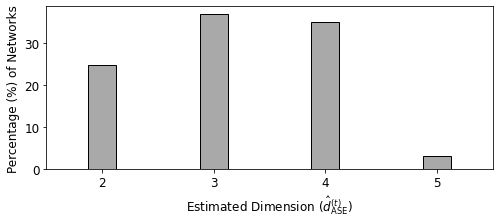

In [101]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.countplot(pd.DataFrame(dims, columns=['d']), 
              x='d', order=['2', '3', '4', '5'],
              stat='percent', color='darkgray', width=0.25,
              edgecolor='k',
              ax=ax)
ax.set_xlabel(r'Estimated Dimension ($\hat{d}_{\text{ASE}}^{(t)}$)', fontsize=12)
ax.set_ylabel('Percentage (%) of Networks', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=12)

# Scree Plot Summary (Figure S.19)

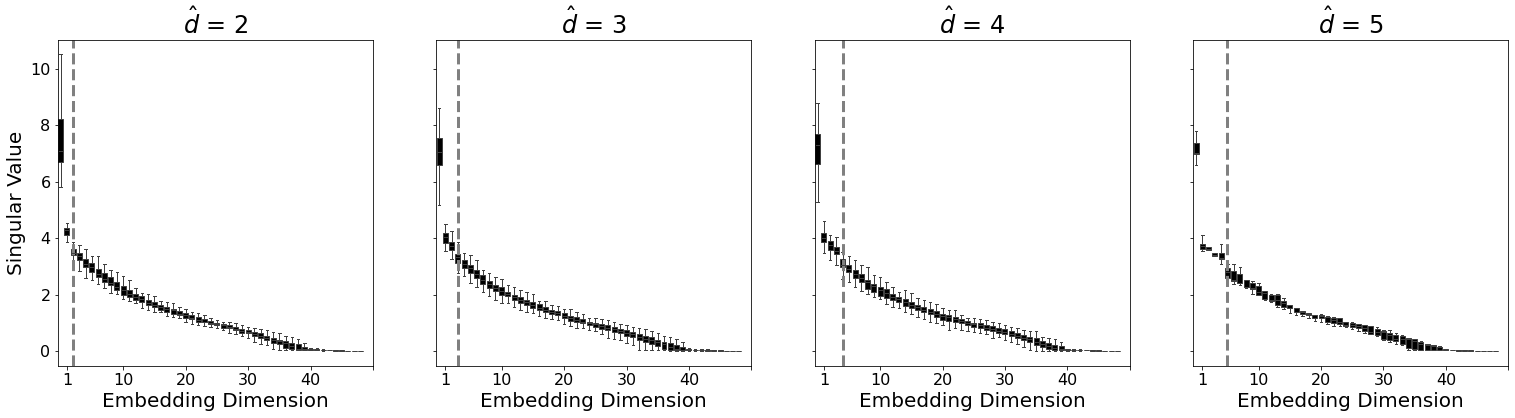

In [102]:
import scipy
from graspologic.utils import augment_diagonal

rng = np.random.default_rng(123)
fig, ax = plt.subplots(figsize=(26, 6), ncols=4, sharey=True, sharex=True)

for idx, d in enumerate([2, 3, 4, 5]):
    ts = np.where(np.asarray(dims) == d)[0]
    Ds = np.zeros((len(ts), Y[0].shape[0]-1))
    for i, t in enumerate(ts):
        D = scipy.sparse.linalg.svds(A=augment_diagonal(Y[t]), k=Y[t].shape[0]-1, return_singular_vectors=False)
        Ds[i] = np.sort(D)[::-1]
    
    sns.boxplot(Ds, color='k', ax=ax[idx], fliersize=0)
    ax[idx].axvline(d, linestyle='--', color='gray', lw=3)
    if idx == 0:
        ax[idx].set_ylabel('Singular Value', fontsize=20)
    ax[idx].set_title(r'$\hat{d}$' + f' = {d}', fontsize=24)
    ax[idx].set_xlabel('Embedding Dimension', fontsize=20)
    ax[idx].set_xticks([1, 10, 20, 30, 40, 50])
    ax[idx].tick_params(axis='both', labelsize=16)

# Individual Scree Plots (Figures S.20)

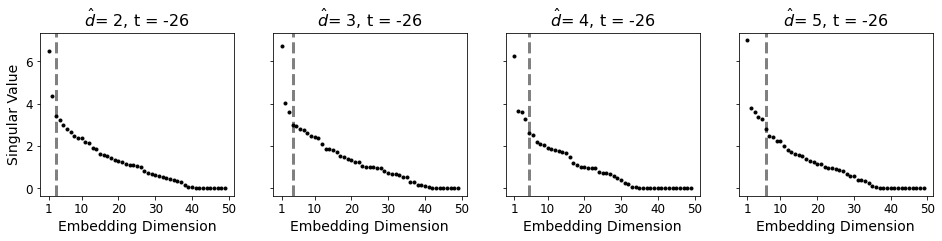

In [103]:
import scipy 
from graspologic.embed import select_dimension
from graspologic.utils import augment_diagonal

letters = ['a', 'b', 'c', 'd']
rng = np.random.default_rng(123)
fig, ax = plt.subplots(figsize=(16, 3), ncols=4, sharey=True, sharex=True)
for i, d in enumerate([2, 3, 4, 5]):
    ts = np.where(np.asarray(dims) == d)[0]
    t = rng.choice(ts)
    D = scipy.sparse.linalg.svds(A=augment_diagonal(Y[t]), k=Y[t].shape[0]-1, return_singular_vectors=False)
    D = np.sort(D)[::-1]
    elbows, singvals = select_dimension(augment_diagonal(Y[t]), n_elbows=2, threshold=None)

    #ax[i].axvline(elbows[0], linestyle='--', color='gray')
    ax[i].axvline(elbows[-1]+1, linestyle='--', color='gray', lw=3)
    ax[i].plot(np.arange(D.shape[0]) + 1, D, 'k.')
    if i == 0:
        ax[i].set_ylabel('Singular Value', fontsize=14)
    ax[i].set_title(r'$\hat{d}$' + f'= {d}, t = {k}', fontsize=16)
    
    ax[i].set_xlabel(f'Embedding Dimension', fontsize=14)
    ax[i].set_xticks([1, 10, 20, 30, 40, 50])
    ax[i].tick_params(axis='both', labelsize=12)

# Sample GB-DASE [RW(2)]

In [78]:
from dynrdpg import DynamicRDPG

rdpg_rw2 = DynamicRDPG(n_features=3, rw_order=2, random_state=10)
rdpg_rw2.sample(Y[:k], n_burnin=5000, n_samples=5000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [38:43<00:00,  4.30it/s]


In [83]:
print('AUC:', rdpg_rw2.auc_)
print('AUPR:', rdpg_rw2.aupr_)

AUC: 0.8550618562452403
AUPR: 0.5124206844167963


# Sample GB-DASE [RW(1)]

In [79]:
from dynrdpg import DynamicRDPG

rdpg_rw1 = DynamicRDPG(n_features=3, rw_order=1)
rdpg_rw1.sample(Y[:k], n_burnin=5000, n_samples=5000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [36:42<00:00,  4.54it/s]


In [82]:
print('AUC:', rdpg_rw1.auc_)
print('AUPR:', rdpg_rw1.aupr_)

AUC: 0.8815408909760358
AUPR: 0.6481815845972905


# Estimate OMNI

In [115]:
from sklearn.metrics import roc_auc_score, log_loss
from dynrdpg.dynrdpg import calculate_auc
from dynrdpg.dynrdpg import dynamic_adjacency_to_vec

from graspologic.embed import OmnibusEmbed as OMNI

y_vec = dynamic_adjacency_to_vec(Y[:k], is_binary=True)
omni = OMNI(n_components=None).fit(Y[:k])

means_omni = []
means_omni_vec = []
for t in range(len(Y[:k])):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    means_omni.append((omni.latent_left_[t] @ omni.latent_left_[t].T))
    means_omni_vec.append(means_omni[t][subdiag])

means_omni = np.clip(np.stack(means_omni), 0, 1)
means_omni_vec = np.clip(np.stack(means_omni_vec), 0, 1)

print('OMNI Dimension:', omni.n_components_)
print('AUC:', roc_auc_score(y_vec.ravel(), means_omni_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_omni_vec.ravel()))

OMNI Dimension: 5
AUC: 0.7678265759151994
AUPR: 0.3618803664974115


## Estimate MASE

In [116]:
from graspologic.embed import MultipleASE as MASE

mase = MASE().fit(Y[:k])
X_mase = mase.latent_left_
means_mase = []
means_mase_vec = []
for t in range(len(Y[:k])):
    subdiag = np.tril_indices(Y[t].shape[0], k=-1)
    R = mase.scores_[t]
    proba_mase = X_mase @ R @ X_mase.T
    means_mase.append(proba_mase)
    means_mase_vec.append(proba_mase[subdiag])

means_mase = np.clip(np.stack(means_mase), 0, 1)
means_mase_vec = np.clip(np.stack(means_mase_vec), 0, 1)

print('MASE Dimension:', X_mase.shape[1])
print('AUC:', roc_auc_score(y_vec.ravel(), means_mase_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_mase_vec.ravel()))

MASE Dimension: 3
AUC: 0.804018182293666
AUPR: 0.3843029689266141


## Estimate UASE

In [117]:
import scipy.sparse as sp
from graspologic.embed import select_dimension

n_nodes, _ = Y[0].shape
A = sp.csr_array(np.hstack([Yt for Yt in Y[:k]]))

d = select_dimension(A)[0][-1]

u, s, vh= sp.linalg.svds(A, k=d)
s_sqrt = np.sqrt(s)[::-1]
X_uase = (vh.T[:, ::-1] * s_sqrt).reshape(len(Y[:k]), n_nodes, d)
Y_uase = u[:, ::-1] * s_sqrt

means_uase = []
means_uase_vec = []
for t in range(X_uase.shape[0]):
    means_uase.append(np.clip(Y_uase @ X_uase[t].T, 0, 1))
    means_uase_vec.append(np.clip(Y_uase @ X_uase[t].T, 0, 1)[subdiag])
means_uase = np.clip(np.stack(means_uase), 0, 1)
means_uase_vec = np.clip(np.stack(means_uase_vec), 0, 1)


print('UASE Dimension:', X_uase.shape[2])
print('AUC:', roc_auc_score(y_vec.ravel(), means_uase_vec.ravel()))
print('AUPR:', average_precision_score(y_vec.ravel(), means_uase_vec.ravel()))

UASE Dimension: 3
AUC: 0.8155293346032778
AUPR: 0.39154356311098926


## Degree Distribution Goodness-of-Fit (Figure S.17) 

## Degree distributions from ASE-based competitors

In [144]:
from dynrdpg.dynamic_gof import degree
import jax.numpy as jnp

n_samples = 100
n_time_steps, n_nodes, _ = Y[:k].shape

deg_dist_ase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_vec))
    deg_dist_ase[idx] = degree(y_sim)
deg_dist_ase = deg_dist_ase.astype(int)

deg_dist_omni = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_omni_vec))
    deg_dist_omni[idx] = degree(y_sim)
deg_dist_omni = deg_dist_omni.astype(int)

deg_dist_mase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_mase_vec))
    deg_dist_mase[idx] = degree(y_sim)
deg_dist_mase = deg_dist_mase.astype(int)

deg_dist_uase = np.zeros((n_samples, n_time_steps, n_nodes))
rng = np.random.RandomState(123)
for idx in range(n_samples):
    y_sim = jnp.asarray(rng.binomial(n=1, p=means_uase_vec))
    deg_dist_uase[idx] = degree(y_sim)
deg_dist_uase = deg_dist_uase.astype(int)

## Posterior Predictive from GB-DASE 

In [145]:
deg_dist_rw2 = rdpg_rw2.posterior_predictive(degree, chunk_size=100)

deg_dist_rw1 = rdpg_rw1.posterior_predictive(degree, chunk_size=100)

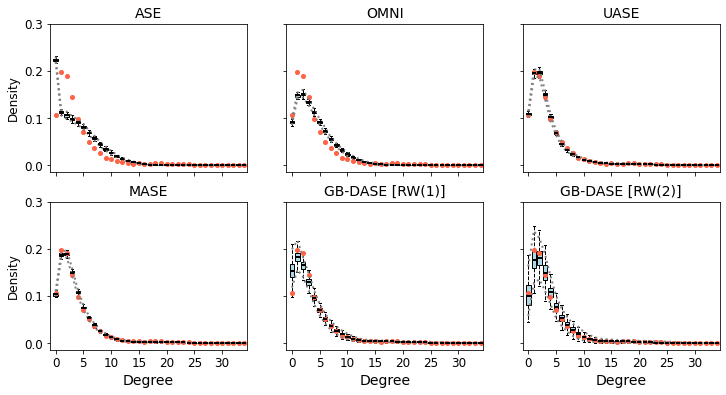

In [148]:
fig, ax = plt.subplots(figsize=(12, 6), ncols=3, nrows=2, sharey=True, sharex=True)
ax = ax.ravel()

BOXPLOT_PROPS = {
    'boxprops': {'facecolor':'#add8e6', 'edgecolor': 'black'},
    'medianprops': {'color': 'black', 'linewidth': 2},
    'whiskerprops': {'color': 'black', 'linestyle': '--'},
    'capprops': {'color': 'black'}
}

deg_dists = [deg_dist_ase, deg_dist_omni, 
             deg_dist_uase, deg_dist_mase,
            deg_dist_rw1, deg_dist_rw2]
names = ['ASE', 'OMNI', 'UASE', 'MASE', 'GB-DASE [RW(1)]', 'GB-DASE [RW(2)]']
for l, deg_dist in enumerate(deg_dists):
    
    n_samples, n_time_points, n_nodes = deg_dist.shape
    deg_pp = deg_dist.reshape(n_samples, n_time_points * n_nodes)

    obs_deg = Y.sum(axis=1)
    max_degree = int(obs_deg.max())
    min_plot, max_plot = 0, max_degree
    deg = np.zeros((deg_pp.shape[0], max_degree + 1))
    for i in range(deg_pp.shape[0]):
        deg[i] = np.bincount(deg_pp[i], minlength=max_degree+1)[:max_degree+1]
        deg[i] /= deg[i].sum()
    
    stat_dist = pd.melt(pd.DataFrame(deg), var_name='degree', value_name='count')

    obs_deg = np.bincount(obs_deg.ravel().astype(int), minlength=max_degree+1)[:max_degree+1]
    sns.boxplot(x='degree', y = 'count', 
            data=stat_dist, ax=ax[l], fliersize=0, **BOXPLOT_PROPS)
    ax[l].plot(obs_deg/obs_deg.sum(), 'o', color='tomato', 
               markersize=4, lw=3)


    bounds = stat_dist.groupby('degree').quantile([0.025, 0.975])
    ax[l].plot(bounds.xs(0.025, level=1).values.ravel(), ':', c='gray', lw=2)
    ax[l].plot(bounds.xs(0.975, level=1).values.ravel(), ':', c='gray', lw=2)
    if l > 3:
        ax[l].set_ylabel('Generalized Posterior\n Predictive Density', fontsize=12)
    else:
        ax[l].set_ylabel('Density', fontsize=12)
    ax[l].set_xlabel('Degree', fontsize=14)
    ax[l].set_xlim(min_plot-1, max_plot + 0.5)
    ax[l].set_xticks(np.arange(min_plot, max_plot+1)[::5])
    ax[l].set_title(names[l], fontsize=14)
    ax[l].tick_params(axis='both', which='major', labelsize=12)

# Forecast Comparison (Table 1)

## GB-DASE [RW(2)] Forecasts

In [118]:
from sklearn.metrics import average_precision_score, roc_auc_score
subdiag = np.tril_indices_from(Y[k], k=-1)

aupr = round(average_precision_score(Y[k][subdiag], rdpg_rw2.probas_[-1]), 4)
print(f"k = 0, AUPR: {aupr}")
    
probas_forecast = rdpg_rw2.forecast(k_steps=4, n_samples=5000, return_subdiag=True)
probas_forecast = probas_forecast.mean(axis=0)
for k_ahead in range(1, 5):
    y_true = Y[k+k_ahead][subdiag]
    forecast = probas_forecast[k_ahead-1]
    aupr = round(average_precision_score(y_true, forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.5362
k = 1, AUPR: 0.4709
k = 2, AUPR: 0.433
k = 3, AUPR: 0.3907
k = 4, AUPR: 0.3752


## GB-DASE [RW(1)] Forecasts

In [119]:
aupr = round(average_precision_score(Y[k][subdiag], rdpg_rw1.probas_[-1]), 4)
print(f"k = 0, AUPR: {aupr}")
    
probas_forecast = rdpg_rw1.forecast(k_steps=4, n_samples=1000, return_subdiag=True)
probas_forecast = probas_forecast.mean(axis=0)
for k_ahead in range(1, 5):
    y_true = Y[k+k_ahead][subdiag]
    forecast = probas_forecast[k_ahead-1]
    aupr = round(average_precision_score(y_true, forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.4938
k = 1, AUPR: 0.4796
k = 2, AUPR: 0.449
k = 3, AUPR: 0.442
k = 4, AUPR: 0.4665


## ASE Forecasts

In [109]:
proba_forecast = means_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.3379
k = 1, AUPR: 0.3413
k = 2, AUPR: 0.3626
k = 3, AUPR: 0.3007
k = 4, AUPR: 0.2856


## OMNI Forecasts

In [110]:
proba_forecast = means_omni_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.4451
k = 1, AUPR: 0.4041
k = 2, AUPR: 0.4366
k = 3, AUPR: 0.3909
k = 4, AUPR: 0.4258


## MASE Forecasts

In [111]:
proba_forecast = means_mase_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.389
k = 1, AUPR: 0.4179
k = 2, AUPR: 0.4361
k = 3, AUPR: 0.3226
k = 4, AUPR: 0.3812


## UASE Forecasts

In [112]:
proba_forecast = means_uase_vec[-1]

for k_ahead in range(0, 5):
    y_true = Y[k+k_ahead][subdiag]
    aupr = round(average_precision_score(y_true, proba_forecast), 4)
    print(f"k = {k_ahead}, AUPR: {aupr}")

k = 0, AUPR: 0.3931
k = 1, AUPR: 0.3891
k = 2, AUPR: 0.4258
k = 3, AUPR: 0.307
k = 4, AUPR: 0.3546


# Palestine-US Conflict Probabilities (Figure 4)

In [142]:
node_names

array(['United States', 'Russia', 'Israel', 'United Kingdom', 'India',
       'Iran', 'China', 'Ukraine', 'European Union', 'Syria', 'Australia',
       'France', 'Germany', 'Japan', 'United Nations', 'Turkey',
       'Afghanistan', 'Pakistan', 'Brazil', 'Canada',
       'Palestinian Territories', 'Belarus',
       'Intergovernmental Organization', 'Colombia', 'Yemen', 'Austria',
       'Venezuela', 'Saudi Arabia', 'Spain', 'Poland', 'Lebanon',
       'South Korea', 'Azerbaijan', 'Iraq', 'Argentina', 'Mexico',
       'Sweden', 'Italy', 'Hong Kong SAR China', 'North Korea', 'Egypt',
       'Armenia', 'Belgium', 'Myanmar [Burma]', 'Taiwan', 'Bulgaria',
       'Nigeria', 'South Africa', 'Georgia', 'Serbia'], dtype=object)

['Palestinian Territories' 'United States']


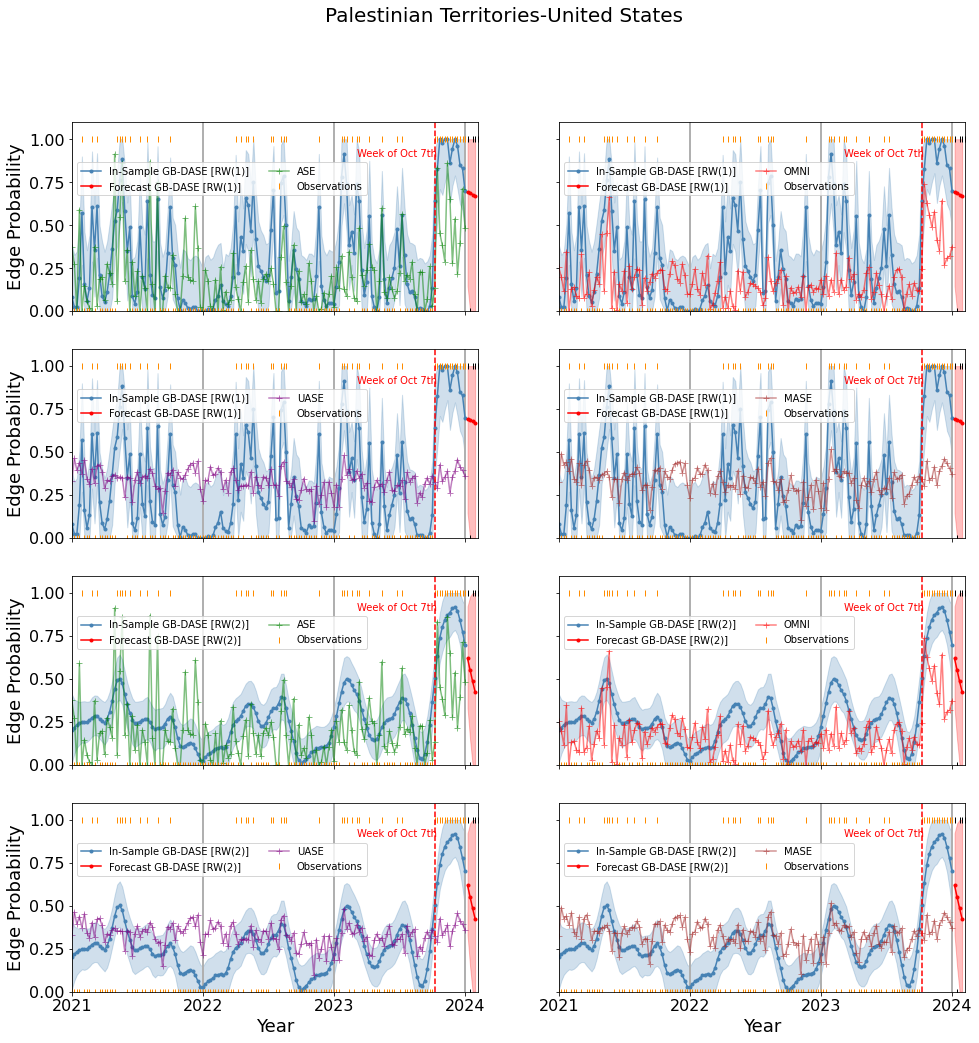

In [152]:
i, j = 20, 0
print(node_names[[i,j]])
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(16, 16), sharey=True, sharex=True)

probas_pred_rw2 = rdpg_rw2.predict(n_samples=2000)
probas_forecast_rw2 = rdpg_rw2.forecast(k_steps=k_steps, n_samples=2500, 
                                        return_subdiag=False)

probas_pred_rw1 = rdpg_rw1.predict(n_samples=2000)
probas_forecast_rw1 = rdpg_rw1.forecast(k_steps=k_steps, n_samples=2500, 
                                        return_subdiag=False)

ax1 = ax[:2, :].ravel()
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax1[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(1)]')
    ax1[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax1[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(1)]')
    ax1[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax1[l].set_xlim(0, n_time_steps + k_steps)
    ax1[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax1[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax1[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax1[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax1[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax1[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax1[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax1[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax1[l].tick_params(axis='both', which='major', labelsize=16)
    ax1[l].axvline(144, c='r', linestyle='--')
    ax1[l].grid(axis='x', lw=2)
    ax1[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    ax1[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax1[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        #ax1[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 
        
ax1 = ax[2:, :].ravel()
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax1[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(2)]')
    ax1[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax1[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(2)]')
    ax1[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax1[l].set_xlim(0, n_time_steps + k_steps)
    ax1[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax1[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax1[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax1[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax1[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax1[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax1[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax1[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax1[l].tick_params(axis='both', which='major', labelsize=16)
    ax1[l].axvline(144, c='r', linestyle='--')
    ax1[l].grid(axis='x', lw=2)
    ax1[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    ax1[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax1[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax1[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20)

fig.savefig('/Users/joshua/myworkspace/generalized-bayes-drdpg/jcgs-submission/first-revision/images/'
            'pl_us_revision.pdf', bbox_inches='tight', dpi=300)

# Israel-UN Conflict Probabilities (Figure S.21)

['Israel' 'United Nations']


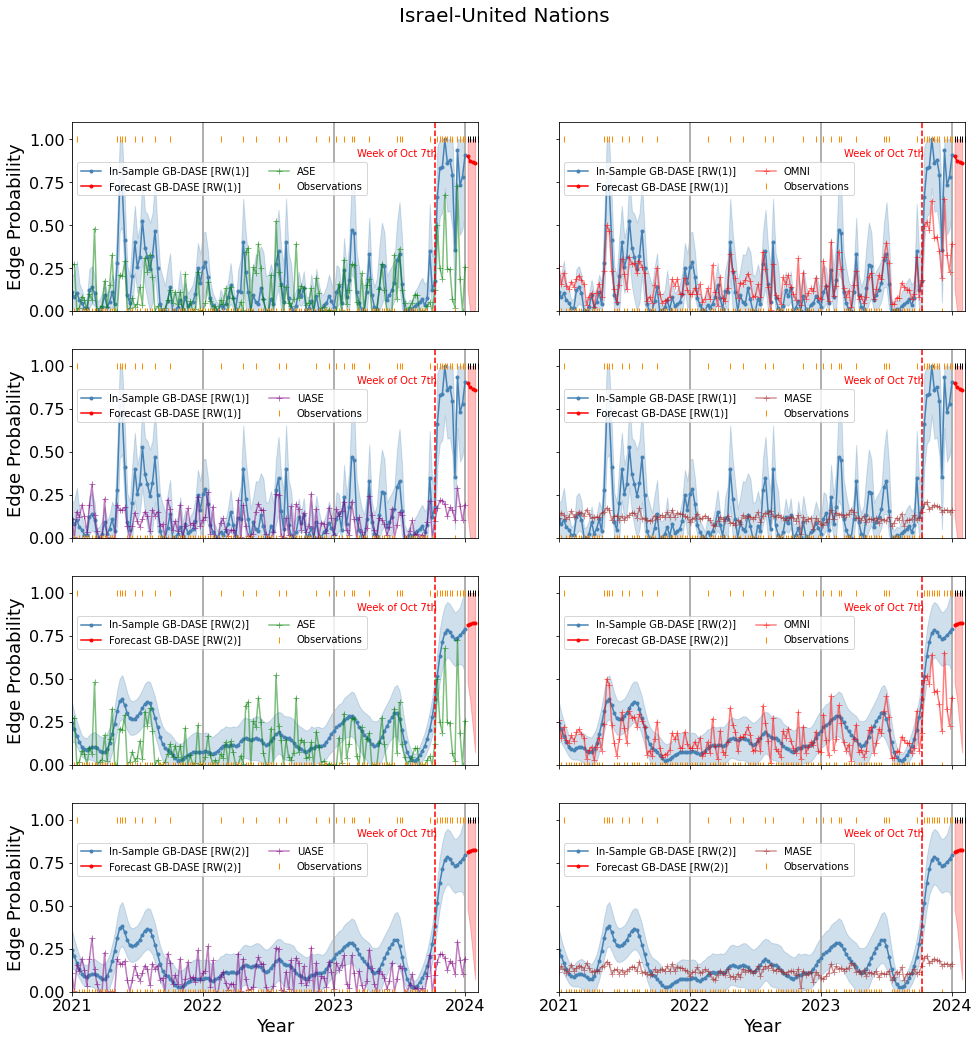

In [151]:
i, j = 2, 14
print(node_names[[i,j]])
Yd = Y[:k].copy()

fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(16, 16), sharey=True, sharex=True)

probas_pred_rw2 = rdpg_rw2.predict(n_samples=2000)
probas_forecast_rw2 = rdpg_rw2.forecast(k_steps=k_steps, n_samples=2500, 
                                        return_subdiag=False)

probas_pred_rw1 = rdpg_rw1.predict(n_samples=2000)
probas_forecast_rw1 = rdpg_rw1.forecast(k_steps=k_steps, n_samples=2500, 
                                        return_subdiag=False)

ax1 = ax[:2, :].ravel()
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax1[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(1)]')
    ax1[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax1[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(1)]')
    ax1[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax1[l].set_xlim(0, n_time_steps + k_steps)
    ax1[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax1[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax1[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax1[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax1[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax1[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax1[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax1[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax1[l].tick_params(axis='both', which='major', labelsize=16)
    ax1[l].axvline(144, c='r', linestyle='--')
    ax1[l].grid(axis='x', lw=2)
    ax1[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    ax1[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax1[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        #ax1[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20) 
        
ax1 = ax[2:, :].ravel()
for l, method in enumerate(['ASE', 'OMNI', 'UASE', 'MASE']):

    n_time_steps, n_nodes, _ = rdpg_rw1.X_.shape

    cis = np.quantile(probas_pred_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax1[l].plot(np.arange(n_time_steps), cis[1], marker='.', color='steelblue', label='In-Sample GB-DASE [RW(2)]')
    ax1[l].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)

    k_steps = 4
    cis = np.quantile(probas_forecast_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax1[l].plot(ts, cis[1], '-', marker='.', color='red', label = 'Forecast GB-DASE [RW(2)]')
    ax1[l].fill_between(ts, cis[0], cis[2], color='red', alpha=0.25)
    ax1[l].set_xlim(0, n_time_steps + k_steps)
    ax1[l].set_ylim(0, 1.1)

    if method == 'ASE':
        ax1[l].plot(means[:, i, j], '+-', color='green', alpha=0.5, label='ASE')
    elif method == 'OMNI':
        ax1[l].plot(means_omni[:, i, j], '+-', color='red', alpha=0.5, label='OMNI')
    elif method == 'MASE':
        ax1[l].plot(means_mase[:, i, j], '+-', color='brown', alpha=0.5, label='MASE')
    elif method == 'UASE':
        ax1[l].plot(means_uase[:, i, j], '+-', color='purple', alpha=0.5, label='UASE')


    ax1[l].plot(Yd[:, i, j], '|', color='darkorange', label='Observations')
    ax1[l].plot(np.arange(len(Yd), len(Yd) - k), Y[k:, i, j], '|', color='black')

    ax1[l].set_xticks([i * 52 for i in range(4)], labels=[2021 + i for i in range(4)], fontsize=20)
    ax1[l].tick_params(axis='both', which='major', labelsize=16)
    ax1[l].axvline(144, c='r', linestyle='--')
    ax1[l].grid(axis='x', lw=2)
    ax1[l].annotate('Week of Oct 7th', (113, 0.9), color='red')
    ax1[l].legend(loc='center left', ncols=2, bbox_to_anchor=(0., 0.7))
    
    #if l in [0, 1]:

    
    if l in [0, 2]:
        ax1[l].set_ylabel('Edge Probability', fontsize=18)
        
    if l in [2, 3]:
        ax1[l].set_xlabel('Year', fontsize=18)

        fig.suptitle(f"{node_names[i]}-{node_names[j]}", fontsize=20)

fig.savefig('/Users/joshua/myworkspace/generalized-bayes-drdpg/jcgs-submission/first-revision/images/'
            'is_un_revision.pdf', bbox_inches='tight', dpi=300)